# 🏠 Grupo 4 — Ames Housing | Fase 2
## Notebook 01: EDA — Exploratory Data Analysis
**CRISP-DM:** Data Understanding

**Integrantes:** Jean Marco · Sergio Arias · Marvin Mollo · Jaime Huaycho · Sergio Mendoza

---
### ¿Qué hacemos en este notebook?
Entendemos el dataset antes de tocar ningún modelo:
- Dimensiones, tipos de datos, valores faltantes
- Distribución del target (`Sale_Price`)
- Variables numéricas: correlaciones y distribuciones
- Variables categóricas: impacto en el precio
- Análisis geoespacial (Neighborhood)
- Hallazgos clave para el preprocesamiento

In [1]:
# ── Instalar dependencias (necesario en Colab) ──────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt', '-q'])

CompletedProcess(args=['C:\\Users\\Karen\\AppData\\Local\\Microsoft\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\python.exe', '-m', 'pip', 'install', '-r', 'requirements.txt', '-q'], returncode=1)

In [2]:
import sys, os, warnings
warnings.filterwarnings('ignore')

project_root = os.getcwd()
while not os.path.exists(os.path.join(project_root, 'config', 'params.yaml')) and project_root != os.path.dirname(project_root):
    project_root = os.path.dirname(project_root)
os.chdir(project_root)
sys.path.insert(0, project_root)
print(f'Directorio: {os.getcwd()}')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data_loader import download_ames_housing
from src.utils import set_plot_style, usd_formatter, save_fig, describe_numeric, check_missing

set_plot_style()
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print('Librerias cargadas correctamente')


Directorio: .../Proyecto-Integrador
Librerias cargadas correctamente


## 1. Carga del Dataset

In [3]:
# ── Descarga desde OpenML (solo la primera vez, luego lee del CSV local) ────
df = download_ames_housing(openml_id=41211, save_dir='data/raw')
print(f'\nDataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head(3)

[INFO] Descargando dataset OpenML ID=41211 ...
[INFO] Dataset guardado en: data/raw\ames_housing_raw.csv  (2930 filas × 81 columnas)
[INFO] Metadata guardada en: data\metadata.json

Dataset cargado: 2,930 filas × 81 columnas


,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,Condition_1,Condition_2,Bldg_Type,House_Style,Overall_Qual,Overall_Cond,Year_Built,Year_Remod_Add,Roof_Style,Roof_Matl,Exterior_1st,Exterior_2nd,Mas_Vnr_Type,...,Fireplace_Qu,Garage_Type,Garage_Finish,Garage_Cars,Garage_Area,Garage_Qual,Garage_Cond,Paved_Drive,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,Three_season_porch,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Longitude,Latitude,Sale_Price
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141.00,"31,770.00",Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Above_Average,Average,"1,960.00","1,960.00",Hip,CompShg,BrkFace,Plywood,Stone,...,Good,Attchd,Fin,2,528.00,Typical,Typical,Partial_Pavement,210.00,62.00,0.00,0.00,0.00,0.00,No_Pool,No_Fence,None,0.00,5,"2,010.00",WD,Normal,-93.62,42.05,"215,000.00"
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80.00,"11,622.00",Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Gtl,North_Ames,Feedr,Norm,OneFam,One_Story,Average,Above_Average,"1,961.00","1,961.00",Gable,CompShg,VinylSd,VinylSd,None,...,No_Fireplace,Attchd,Unf,1,730.00,Typical,Typical,Paved,140.00,0.00,0.00,0.00,120.00,0.00,No_Pool,Minimum_Privacy,None,0.00,6,"2,010.00",WD,Normal,-93.62,42.05,"105,000.00"
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81.00,"14,267.00",Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Above_Average,Above_Average,"1,958.00","1,958.00",Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,...,No_Fireplace,Attchd,Unf,1,312.00,Typical,Typical,Paved,393.00,36.00,0.00,0.00,0.00,0.00,No_Pool,No_Fence,Gar2,"12,500.00",6,"2,010.00",WD,Normal,-93.62,42.05,"172,000.00"


## 2. Información General del Dataset

In [4]:
# ── Resumen de tipos de datos ────────────────────────────────────────────────
# El dataset viene con tipos bien definidos desde OpenML:
# - float64 / uint8 para numéricas
# - category para categóricas (nominales y ordinales)

print('=== Tipos de datos ===')
print(df.dtypes.value_counts())
print(f'\nTotal columnas: {df.shape[1]}')
print(f'  Numéricas  : {df.select_dtypes(include="number").shape[1]}')
print(f'  Categóricas: {df.select_dtypes(include="category").shape[1]}')

=== Tipos de datos ===
float64     24
uint8       11
category     3
category     2
category     2
category     2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

Total columnas: 81
  Numéricas  : 35
  Categóricas: 46


In [5]:
# ── Verificar valores faltantes ──────────────────────────────────────────────
# Importante: la versión OpenML ya procesó los NaN de la mayoría de variables.
# Verificamos cuántos quedan realmente.

missing = df.isnull().sum()
total_missing = missing.sum()
print(f'Total valores faltantes en el dataset: {total_missing}')

if total_missing > 0:
    print('\nColumnas con missing values:')
    print(missing[missing > 0].sort_values(ascending=False))
else:
    print('✅ No hay valores faltantes (la versión OpenML ya los imputó con valores categóricos como "No_Basement")')
    print('\n⚠️  HALLAZGO: Las categorías como "No_Basement", "No_Garage", "No_Alley_Access" representan')
    print('   la AUSENCIA de esa característica. No son NaN reales, pero deben mapearse a 0 en preprocesamiento.')

Total valores faltantes en el dataset: 0
✅ No hay valores faltantes (la versión OpenML ya los imputó con valores categóricos como "No_Basement")

⚠️  HALLAZGO: Las categorías como "No_Basement", "No_Garage", "No_Alley_Access" representan
   la AUSENCIA de esa característica. No son NaN reales, pero deben mapearse a 0 en preprocesamiento.


In [6]:
# ── Resumen estadístico de variables numéricas ───────────────────────────────
# Incluye skewness y kurtosis — importantes para saber qué necesita log-transform

num_summary = describe_numeric(df)

# Variables con skew > 1 (candidatas a transformación logarítmica)
high_skew = num_summary[num_summary['skew'].abs() > 1].sort_values('skew', ascending=False)
print(f'Variables numéricas con |skew| > 1 (candidatas a log-transform): {len(high_skew)}')
print(high_skew[['mean', 'std', 'min', 'max', 'skew']].head(10).to_string())

Variables numéricas con |skew| > 1 (candidatas a log-transform): 17
                        mean      std      min        max  skew
Misc_Val               50.63   566.34     0.00  17,000.00 22.00
Pool_Area               2.24    35.60     0.00     800.00 16.94
Lot_Area           10,147.92 7,880.02 1,300.00 215,245.00 12.82
Low_Qual_Fin_SF         4.68    46.31     0.00   1,064.00 12.12
Three_season_porch      2.59    25.14     0.00     508.00 11.40
Kitchen_AbvGr           1.04     0.21     0.00       3.00  4.31
BsmtFin_SF_2           49.70   169.14     0.00   1,526.00  4.14
Enclosed_Porch         23.01    64.14     0.00   1,012.00  4.01
Screen_Porch           16.00    56.09     0.00     576.00  3.96
Bsmt_Half_Bath          0.06     0.24     0.00       2.00  3.94


## 3. Análisis del Target: Sale_Price

[Fig] Guardada: reports/figures\01_target_distribution.png


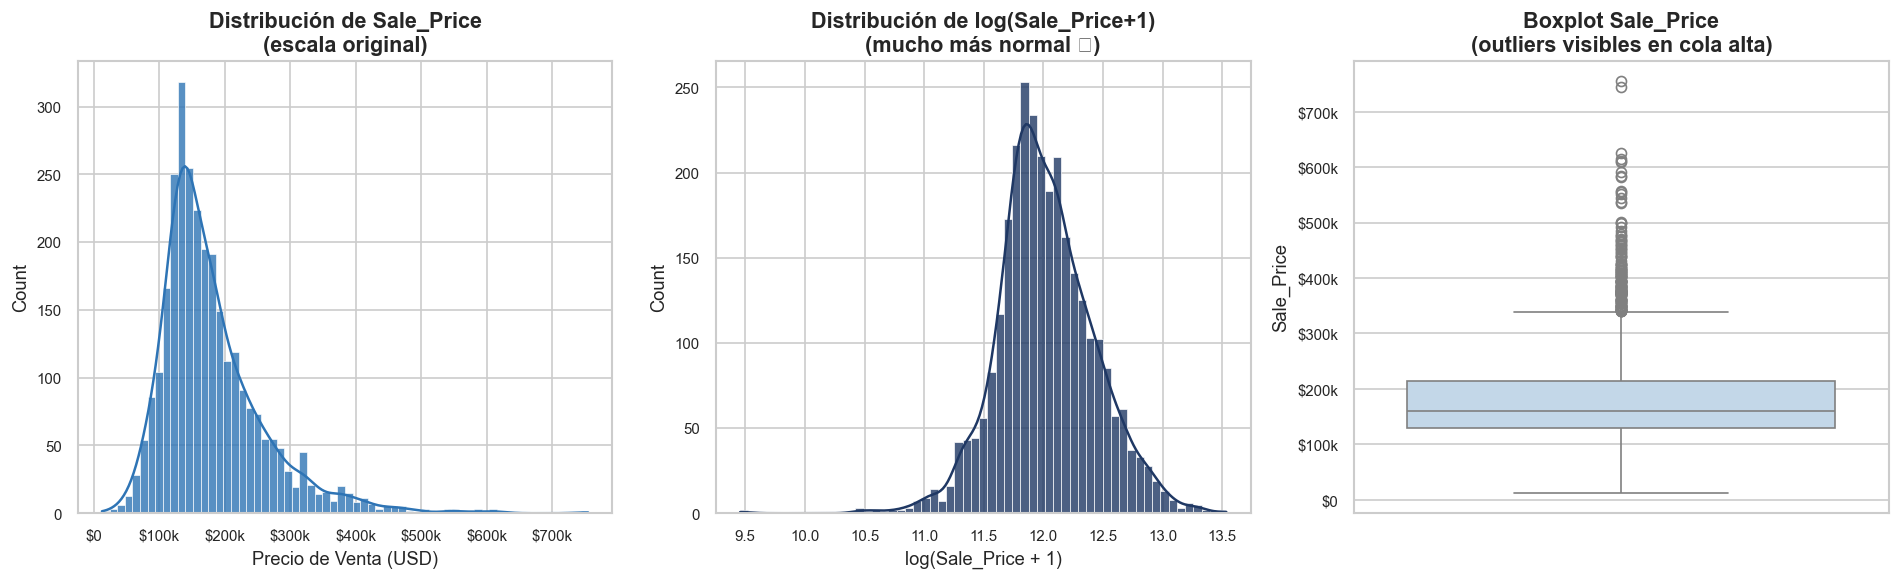


=== Estadísticas de Sale_Price ===
  count   : $2,930
  mean    : $180,796
  std     : $79,887
  min     : $12,789
  25%     : $129,500
  50%     : $160,000
  75%     : $213,500
  max     : $755,000
  Skewness: 1.744

💡 HALLAZGO: Skewness = 1.88 → distribución claramente asimétrica.
   Aplicaremos log1p(Sale_Price) como target para los modelos.


In [7]:
# ── Distribución del precio de venta ────────────────────────────────────────
# HALLAZGO: distribución right-skewed → log-transform mejora los modelos lineales

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Distribución original
sns.histplot(df['Sale_Price'], kde=True, ax=axes[0], color='#2E74B5', alpha=0.8)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(usd_formatter))
axes[0].set_title('Distribución de Sale_Price\n(escala original)', fontweight='bold')
axes[0].set_xlabel('Precio de Venta (USD)')

# Panel 2: Log-transform
sns.histplot(np.log1p(df['Sale_Price']), kde=True, ax=axes[1], color='#1F3864', alpha=0.8)
axes[1].set_title('Distribución de log(Sale_Price+1)\n(mucho más normal ✅)', fontweight='bold')
axes[1].set_xlabel('log(Sale_Price + 1)')

# Panel 3: Boxplot para outliers
sns.boxplot(y=df['Sale_Price'], ax=axes[2], color='#BDD7EE')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(usd_formatter))
axes[2].set_title('Boxplot Sale_Price\n(outliers visibles en cola alta)', fontweight='bold')

plt.tight_layout()
save_fig('01_target_distribution')
plt.show()

# Stats del target
print('\n=== Estadísticas de Sale_Price ===')
stats = df['Sale_Price'].describe()
for k, v in stats.items():
    print(f'  {k:8s}: ${v:,.0f}')
print(f'  Skewness: {df["Sale_Price"].skew():.3f}')
print('\n💡 HALLAZGO: Skewness = 1.88 → distribución claramente asimétrica.')
print('   Aplicaremos log1p(Sale_Price) como target para los modelos.')

[Fig] Guardada: reports/figures\02_price_by_year.png


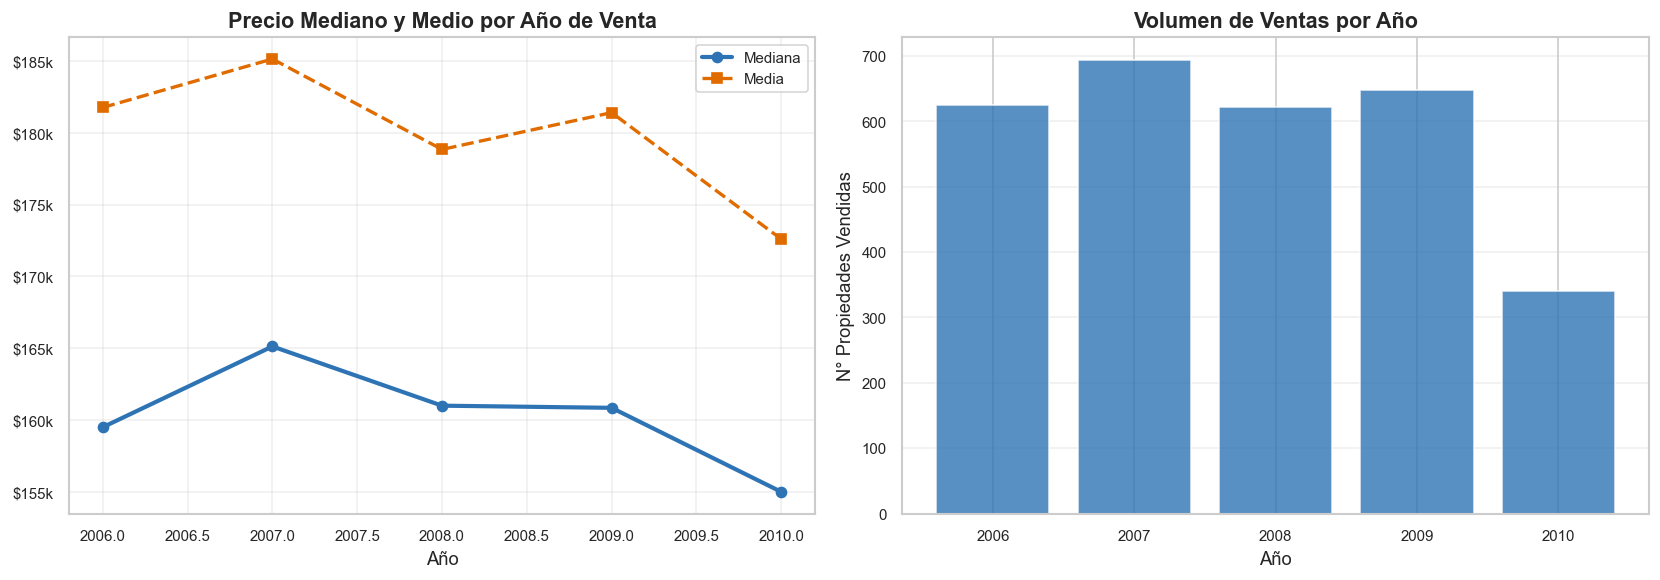

💡 HALLAZGO: El precio mediano cae ligeramente en 2008-2009 (crisis hipotecaria),
   pero Ames es más estable que mercados especulativos. Volumen cae 2008-2009.


In [8]:
# ── Evolución del precio por año de venta ───────────────────────────────────
# ¿Notamos el impacto de la crisis 2008?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precio mediano por año
yearly = df.groupby('Year_Sold')['Sale_Price'].agg(['median', 'mean', 'count']).reset_index()
axes[0].plot(yearly['Year_Sold'], yearly['median'], 'o-', color='#2E74B5', linewidth=2.5, label='Mediana')
axes[0].plot(yearly['Year_Sold'], yearly['mean'],   's--', color='#E06C00', linewidth=2, label='Media')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(usd_formatter))
axes[0].set_title('Precio Mediano y Medio por Año de Venta', fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Volumen de ventas por año
axes[1].bar(yearly['Year_Sold'], yearly['count'], color='#2E74B5', alpha=0.8, edgecolor='white')
axes[1].set_title('Volumen de Ventas por Año', fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('N° Propiedades Vendidas')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_fig('02_price_by_year')
plt.show()

print('💡 HALLAZGO: El precio mediano cae ligeramente en 2008-2009 (crisis hipotecaria),')
print('   pero Ames es más estable que mercados especulativos. Volumen cae 2008-2009.')

## 4. Análisis de Variables Numéricas

[Fig] Guardada: reports/figures\03_top_correlations.png


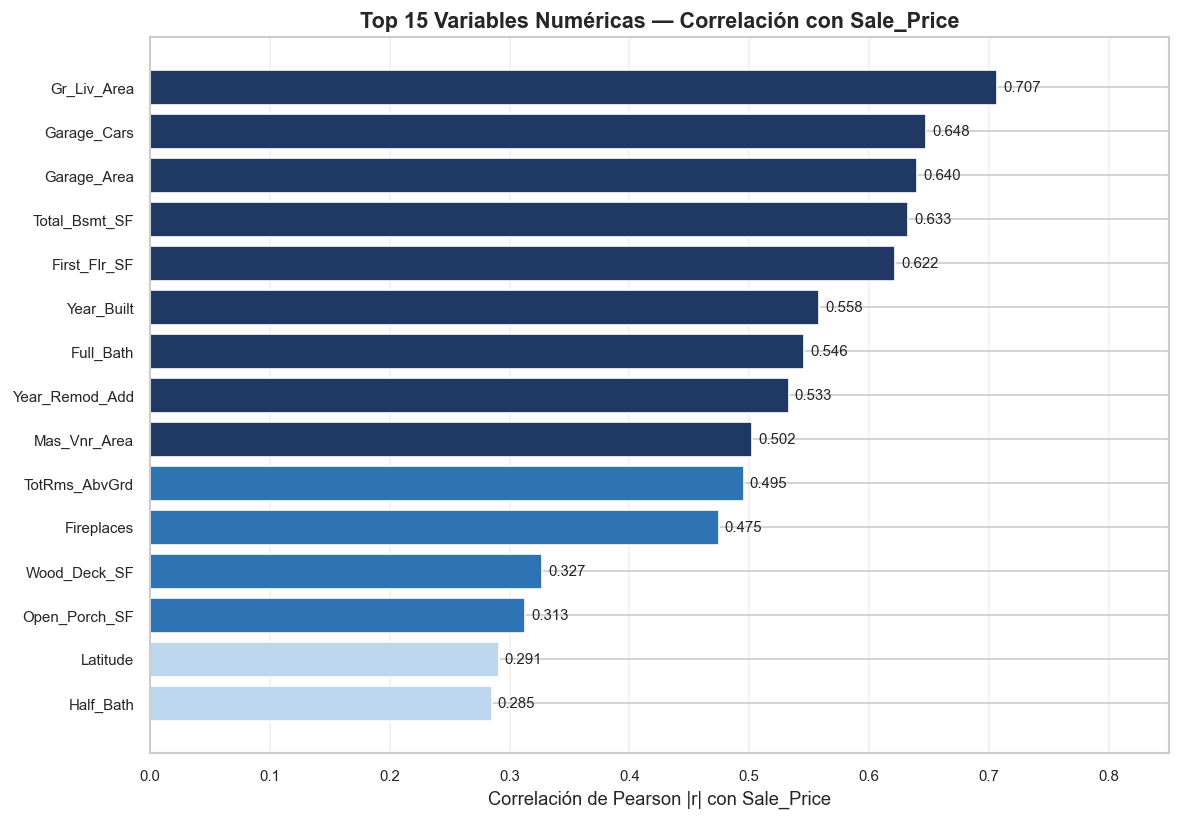

💡 HALLAZGO: Overall_Qual tiene la mayor correlación (r≈0.79) aunque viene como
   variable categórica → la convertiremos a ordinal numérica en preprocesamiento.

   Top 5 correlaciones:
   Gr_Liv_Area              : r = 0.707
   Garage_Cars              : r = 0.648
   Garage_Area              : r = 0.640
   Total_Bsmt_SF            : r = 0.633
   First_Flr_SF             : r = 0.622


In [9]:
# ── Top correlaciones con Sale_Price ────────────────────────────────────────
# ¿Qué variables numéricas predicen mejor el precio?

num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()['Sale_Price'].drop('Sale_Price').abs().sort_values(ascending=False)

top15 = corr.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#1F3864' if c > 0.5 else '#2E74B5' if c > 0.3 else '#BDD7EE' for c in top15.values]
bars = ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1], edgecolor='white')

# Anotar valores
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Correlación de Pearson |r| con Sale_Price', fontsize=11)
ax.set_title('Top 15 Variables Numéricas — Correlación con Sale_Price', fontsize=13, fontweight='bold')
ax.set_xlim(0, 0.85)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
save_fig('03_top_correlations')
plt.show()

print('💡 HALLAZGO: Overall_Qual tiene la mayor correlación (r≈0.79) aunque viene como')
print('   variable categórica → la convertiremos a ordinal numérica en preprocesamiento.')
print(f'\n   Top 5 correlaciones:')
for feat, corr_val in top15.head(5).items():
    print(f'   {feat:25s}: r = {corr_val:.3f}')

[Fig] Guardada: reports/figures\04_correlation_heatmap.png


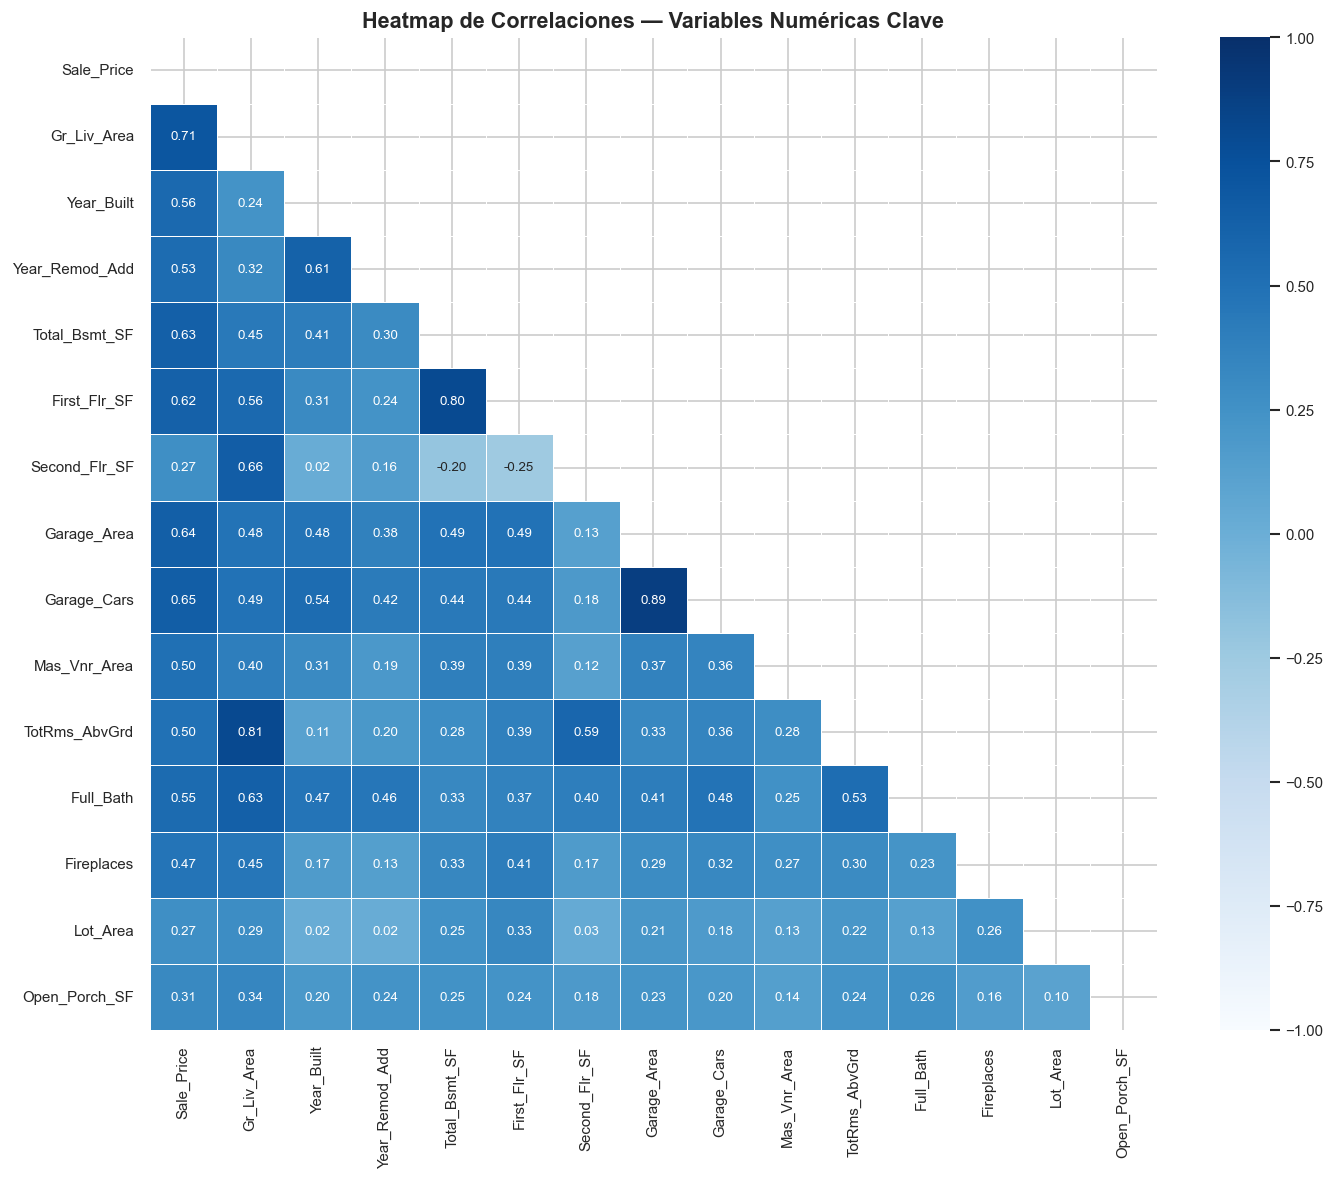

💡 HALLAZGO — Multicolinealidad detectada:
   Garage_Area ↔ Garage_Cars: r=0.890 → Posible multicolinealidad
   Gr_Liv_Area ↔ TotRms_AbvGrd: r=0.808 → Posible multicolinealidad
   Total_Bsmt_SF ↔ First_Flr_SF: r=0.800 → Posible multicolinealidad


In [10]:
# ── Heatmap de correlaciones entre top variables numéricas ─────────────────
# Importante para detectar multicolinealidad

top_num_vars = ['Sale_Price', 'Gr_Liv_Area', 'Year_Built', 'Year_Remod_Add',
                'Total_Bsmt_SF', 'First_Flr_SF', 'Second_Flr_SF',
                'Garage_Area', 'Garage_Cars', 'Mas_Vnr_Area',
                'TotRms_AbvGrd', 'Full_Bath', 'Fireplaces',
                'Lot_Area', 'Open_Porch_SF']

# Algunas pueden ser category con valores numéricos en este dataset
available = [c for c in top_num_vars if c in df.select_dtypes(include='number').columns]

corr_matrix = df[available].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='Blues',
    linewidths=0.5, linecolor='white',
    vmin=-1, vmax=1, center=0,
    annot_kws={'size': 8}
)
plt.title('Heatmap de Correlaciones — Variables Numéricas Clave', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('04_correlation_heatmap')
plt.show()

# Detectar pares muy correlacionados (multicolinealidad)
print('💡 HALLAZGO — Multicolinealidad detectada:')
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        c = abs(corr_matrix.iloc[i, j])
        if c > 0.80 and corr_matrix.columns[i] != 'Sale_Price' and corr_matrix.columns[j] != 'Sale_Price':
            corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], c))

for v1, v2, c in sorted(corr_pairs, key=lambda x: -x[2]):
    print(f'   {v1} ↔ {v2}: r={c:.3f} → Posible multicolinealidad')

[Fig] Guardada: reports/figures\05_scatter_top_features.png


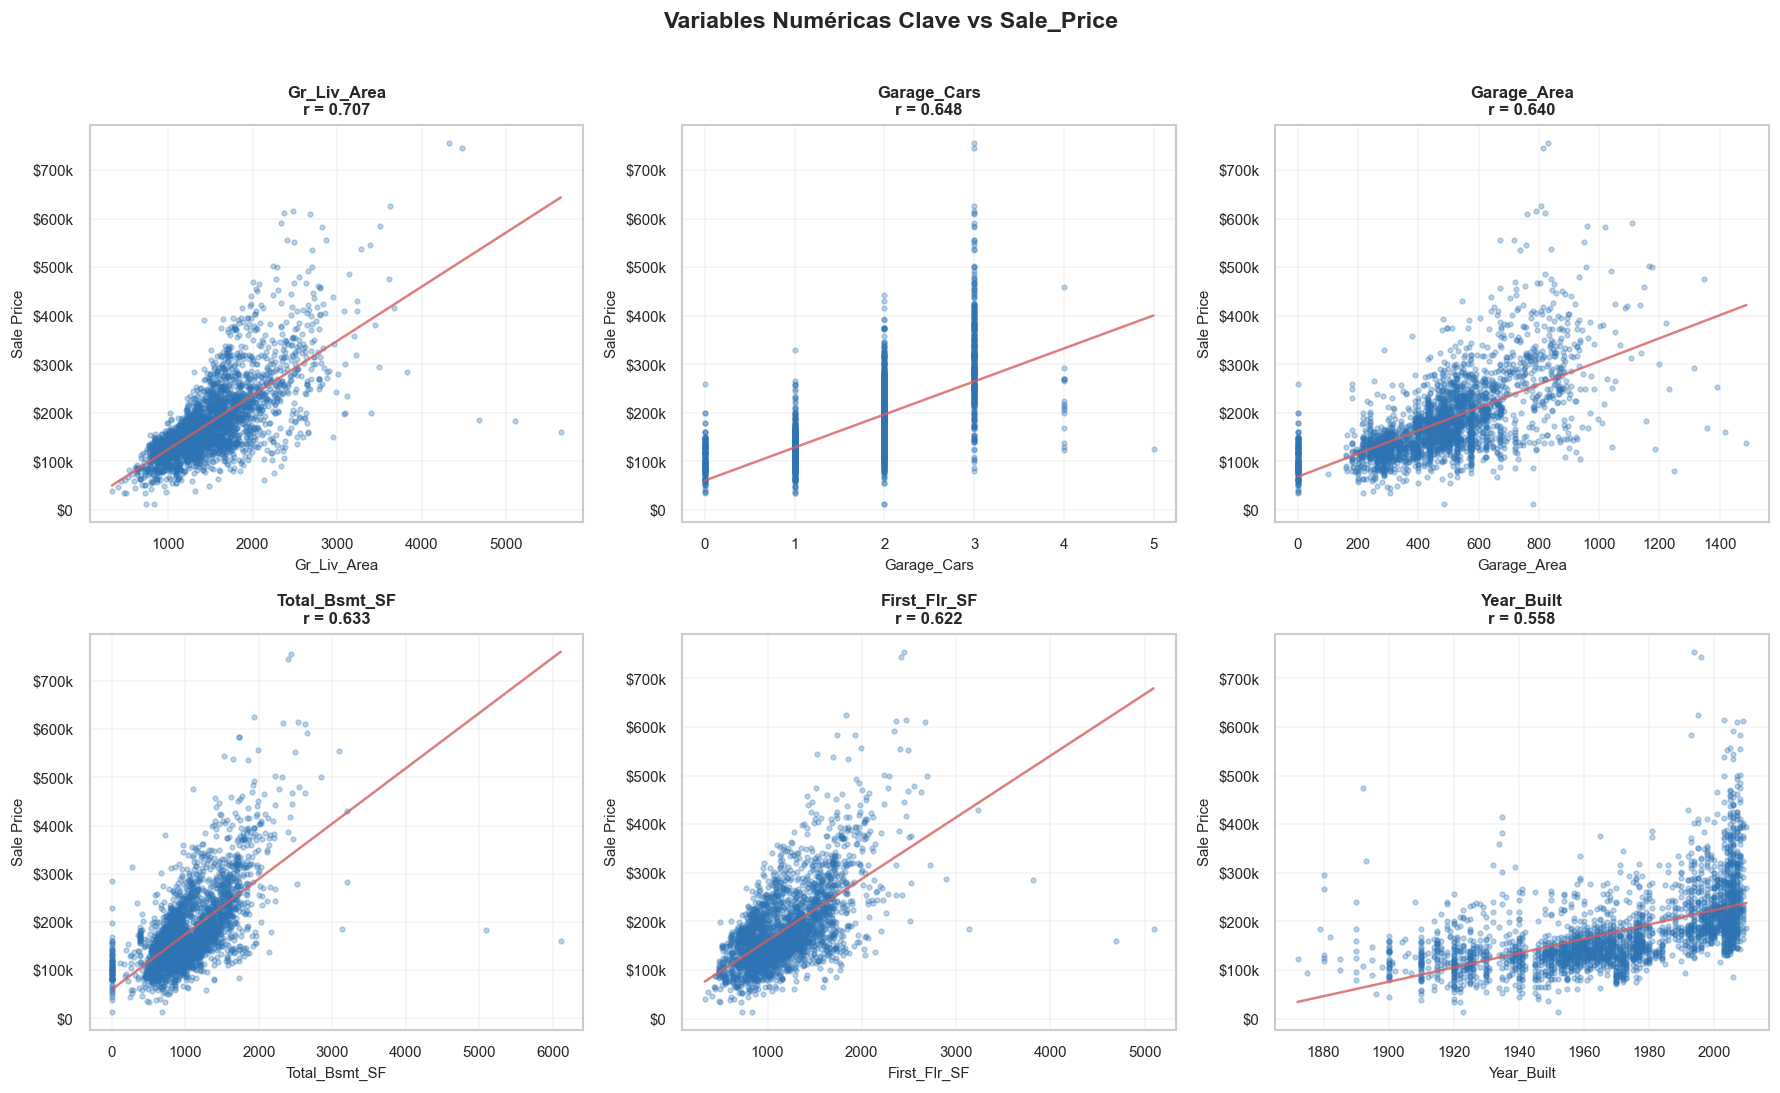

💡 HALLAZGO: Gr_Liv_Area muestra 2 propiedades con área > 4000 ft² pero precio bajo.
   Son ventas atípicas documentadas por De Cock (2011). Las eliminaremos.


In [11]:
# ── Scatter plots: las 6 variables más correlacionadas vs Sale_Price ────────
# Visualizar la relación directa: ¿es lineal, cuadrática, con ruido?

top6_num = [c for c in corr.head(8).index if c in df.select_dtypes(include='number').columns][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(top6_num):
    axes[i].scatter(df[col], df['Sale_Price'], alpha=0.3, s=8, color='#2E74B5')
    # Línea de tendencia
    m, b = np.polyfit(df[col].fillna(0), df['Sale_Price'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m*x_line + b, 'r-', linewidth=1.5, alpha=0.8)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Sale Price', fontsize=9)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(usd_formatter))
    r_val = corr[col] if col in corr.index else 0
    axes[i].set_title(f'{col}\nr = {r_val:.3f}', fontweight='bold', fontsize=10)
    axes[i].grid(True, alpha=0.2)

plt.suptitle('Variables Numéricas Clave vs Sale_Price', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig('05_scatter_top_features')
plt.show()

print('💡 HALLAZGO: Gr_Liv_Area muestra 2 propiedades con área > 4000 ft² pero precio bajo.')
print('   Son ventas atípicas documentadas por De Cock (2011). Las eliminaremos.')

## 5. Análisis de Variables Categóricas

[Fig] Guardada: reports/figures\06_neighborhood_price.png


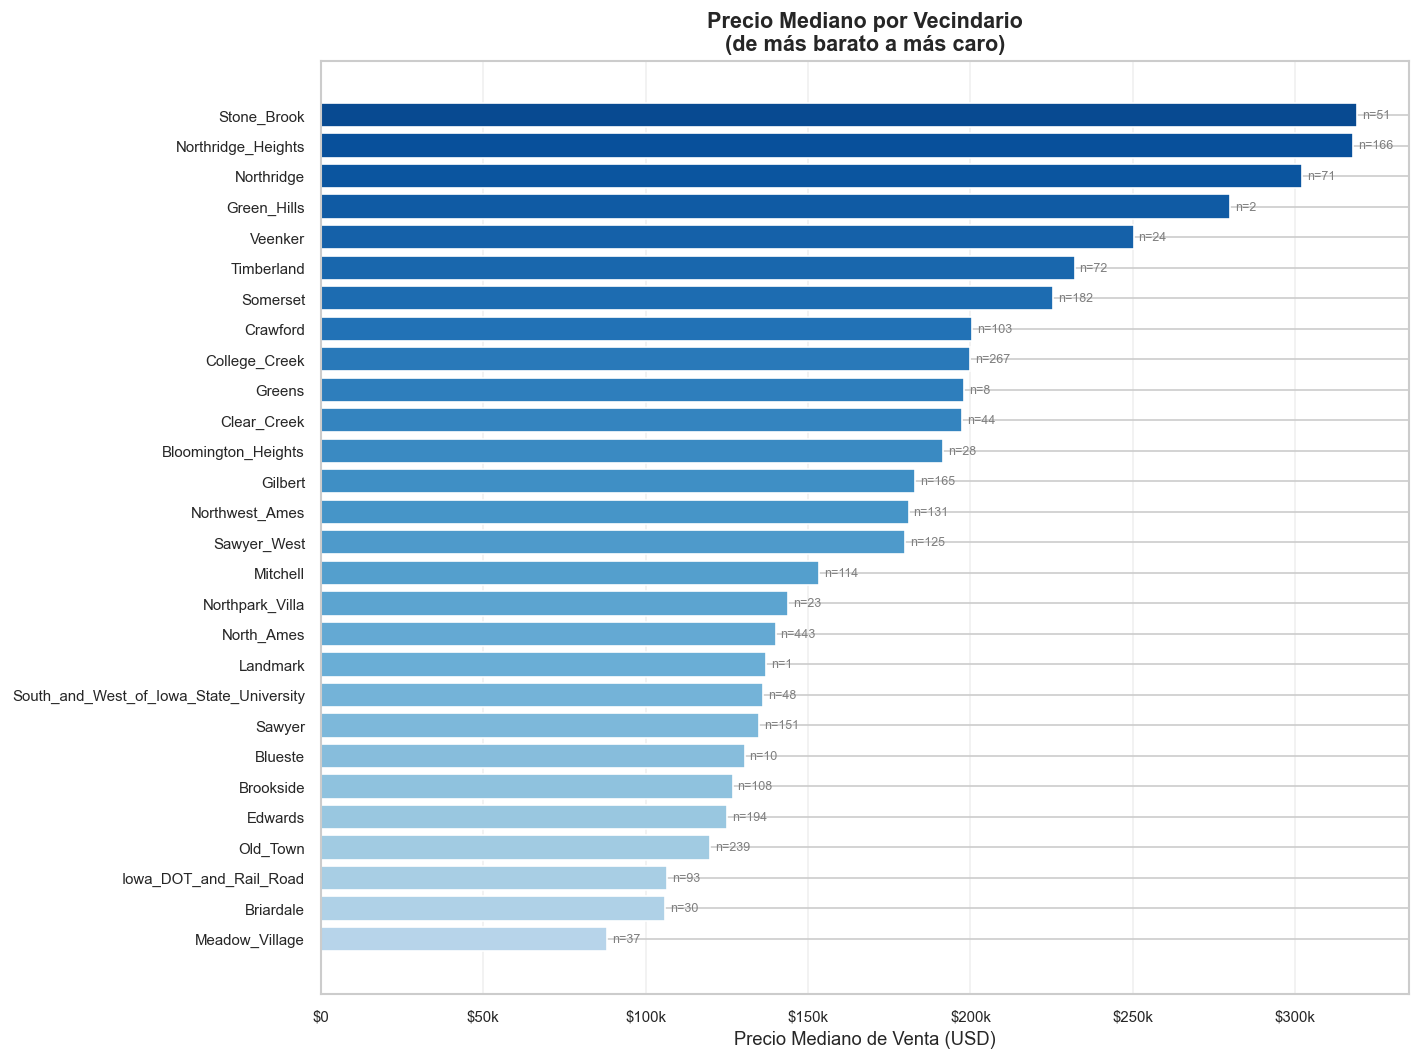

💡 HALLAZGO: Diferencia entre vecindario más caro (Stone_Brook)
   y más barato (Meadow_Village): $230,750 USD
   Ratio: 3.6x → el vecindario multiplica el precio hasta 3.6 veces.
   → Usaremos Target Encoding para esta variable en el modelo.


In [12]:
# ── Neighborhood: variable categórica de MAYOR impacto en precio ────────────
# Con 28 vecindarios, es la variable nominal con más poder predictivo

# Calcular precio mediano por vecindario
neigh_price = df.groupby('Neighborhood')['Sale_Price'].agg(['median', 'count']).reset_index()
neigh_price.columns = ['Neighborhood', 'Median_Price', 'Count']
neigh_price = neigh_price.sort_values('Median_Price', ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(neigh_price)))
bars = ax.barh(neigh_price['Neighborhood'], neigh_price['Median_Price'],
               color=colors, edgecolor='white')

# Anotar conteo de propiedades
for bar, n in zip(bars, neigh_price['Count']):
    ax.text(bar.get_width() + 1500, bar.get_y() + bar.get_height()/2,
            f'n={n}', va='center', fontsize=7.5, color='gray')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(usd_formatter))
ax.set_xlabel('Precio Mediano de Venta (USD)', fontsize=11)
ax.set_title('Precio Mediano por Vecindario\n(de más barato a más caro)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
save_fig('06_neighborhood_price')
plt.show()

# Diferencia entre vecindario más caro y más barato
max_p = neigh_price['Median_Price'].max()
min_p = neigh_price['Median_Price'].min()
print(f'💡 HALLAZGO: Diferencia entre vecindario más caro ({neigh_price.iloc[-1]["Neighborhood"]})')
print(f'   y más barato ({neigh_price.iloc[0]["Neighborhood"]}): ${max_p - min_p:,.0f} USD')
print(f'   Ratio: {max_p/min_p:.1f}x → el vecindario multiplica el precio hasta {max_p/min_p:.1f} veces.')
print('   → Usaremos Target Encoding para esta variable en el modelo.')

[Fig] Guardada: reports/figures\07_quality_price.png


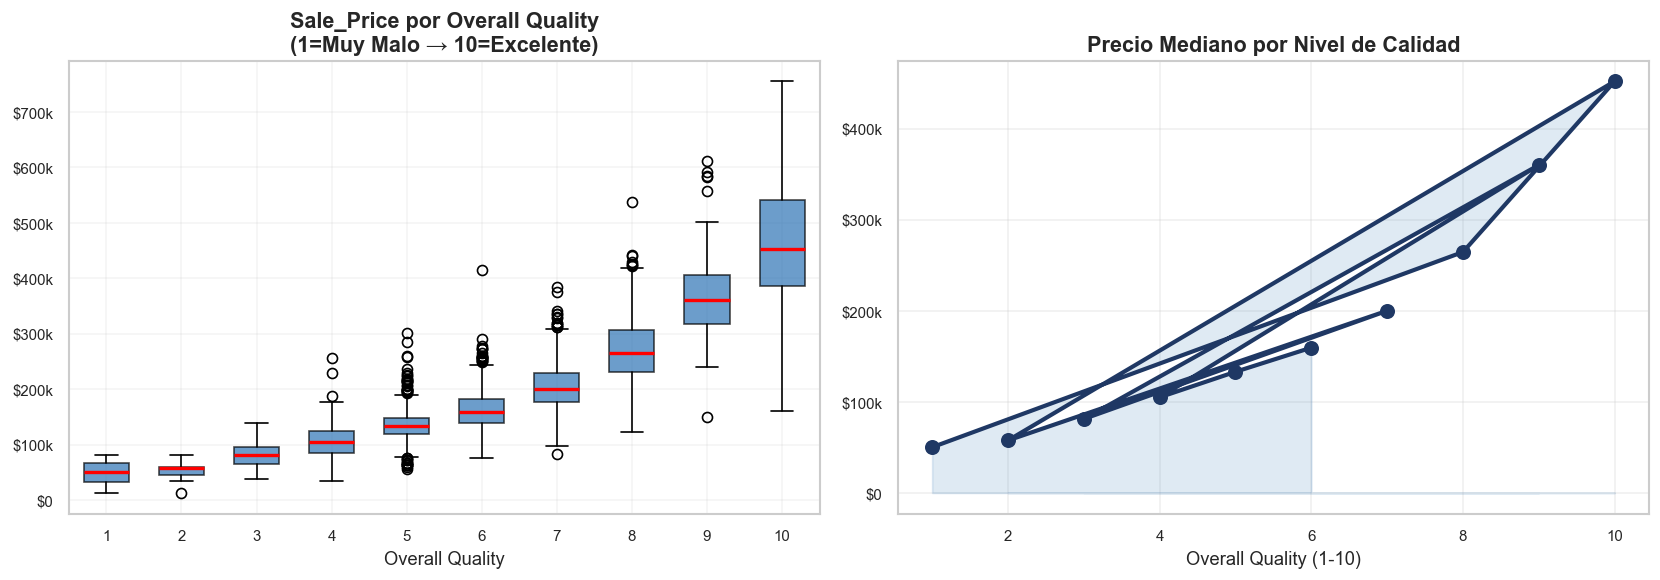

💡 HALLAZGO: La relación calidad-precio es casi EXPONENCIAL.
   A mayor calidad, significativamente mayor precio de venta.


In [13]:
# ── Overall Quality: la variable de mayor correlación con precio ─────────────

# Mapeo de texto a número
qual_map = {
    'Very_Poor': 1, 'Poor': 2, 'Fair': 3,
    'Below_Average': 4, 'Average': 5, 'Above_Average': 6,
    'Good': 7, 'Very_Good': 8, 'Excellent': 9, 'Very_Excellent': 10
}

df['Overall_Qual_Num'] = df['Overall_Qual'].map(qual_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: boxplot
for q in sorted(df['Overall_Qual_Num'].dropna().unique()):
    datos = df[df['Overall_Qual_Num'] == q]['Sale_Price']
    axes[0].boxplot(datos, positions=[q], widths=0.6,
                    patch_artist=True,
                    boxprops=dict(facecolor='#2E74B5', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))

axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(usd_formatter))
axes[0].set_title('Sale_Price por Overall Quality\n(1=Muy Malo → 10=Excelente)', fontweight='bold')
axes[0].set_xlabel('Overall Quality')
axes[0].set_xticks(list(qual_map.values()))
axes[0].grid(True, alpha=0.2)

# Panel 2: precio mediano por calidad
qual_median = df.groupby('Overall_Qual_Num')['Sale_Price'].median().dropna().sort_index()
axes[1].plot(qual_median.index, qual_median.values, 'o-', color='#1F3864', linewidth=2.5, markersize=8)
axes[1].fill_between(qual_median.index, qual_median.values, alpha=0.15, color='#2E74B5')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(usd_formatter))
axes[1].set_title('Precio Mediano por Nivel de Calidad', fontweight='bold')
axes[1].set_xlabel('Overall Quality (1-10)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_fig('07_quality_price')
plt.show()

print(f'💡 HALLAZGO: La relación calidad-precio es casi EXPONENCIAL.')
print(f'   A mayor calidad, significativamente mayor precio de venta.')

df.drop(columns=['Overall_Qual_Num'], inplace=True)

In [14]:
print(df['Overall_Qual'].dtype)
print(df['Overall_Qual'].value_counts().head(10))

category
Overall_Qual
Average           825
Above_Average     732
Good              602
Very_Good         350
Below_Average     226
Excellent         107
Fair               40
Very_Excellent     31
Poor               13
Very_Poor           4
Name: count, dtype: int64


[Fig] Guardada: reports/figures\08_key_features.png


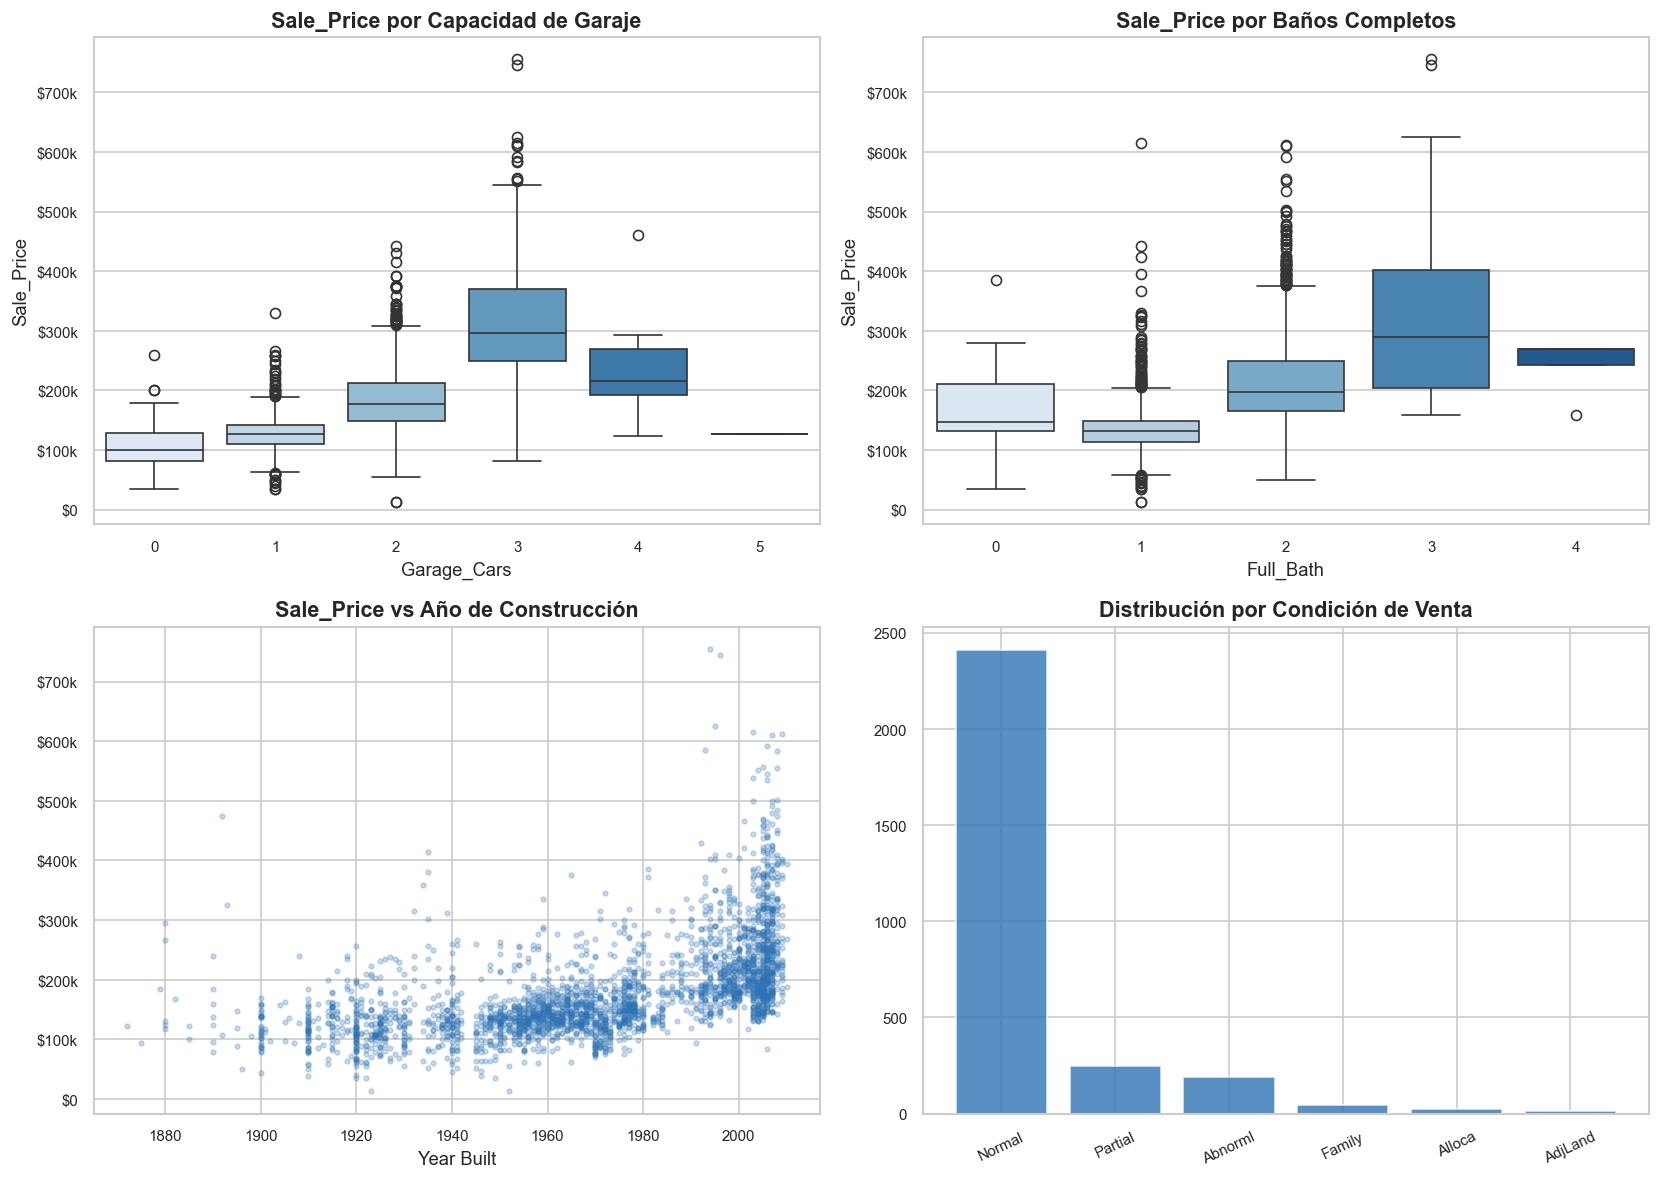

💡 HALLAZGO: 82.4% de las ventas son de tipo Normal.
   Las ventas no-normales (Partial, Abnorml, etc.) pueden tener precios atípicos.
   Considerar si incluirlas o filtrarlas en el modelo.


In [15]:
# ── Garage, Basement y otras variables clave ─────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Garage Cars vs Sale Price
palette_g = sns.color_palette('Blues', n_colors=df['Garage_Cars'].nunique())
sns.boxplot(data=df, x='Garage_Cars', y='Sale_Price', palette=palette_g, ax=axes[0,0])
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(usd_formatter))
axes[0,0].set_title('Sale_Price por Capacidad de Garaje', fontweight='bold')

# Full Bath vs Sale Price
palette_b = sns.color_palette('Blues', n_colors=df['Full_Bath'].nunique())
sns.boxplot(data=df, x='Full_Bath', y='Sale_Price', palette=palette_b, ax=axes[0,1])
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(usd_formatter))
axes[0,1].set_title('Sale_Price por Baños Completos', fontweight='bold')

# Año de construcción vs precio (scatter)
axes[1,0].scatter(df['Year_Built'], df['Sale_Price'], alpha=0.25, s=8, color='#2E74B5')
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(usd_formatter))
axes[1,0].set_title('Sale_Price vs Año de Construcción', fontweight='bold')
axes[1,0].set_xlabel('Year Built')

# Sale_Type distribution (nos interesa si dominan las ventas normales)
sale_counts = df['Sale_Condition'].value_counts()
axes[1,1].bar(sale_counts.index, sale_counts.values, color='#2E74B5', alpha=0.8, edgecolor='white')
axes[1,1].set_title('Distribución por Condición de Venta', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=25)

plt.tight_layout()
save_fig('08_key_features')
plt.show()

normal_pct = (df['Sale_Condition'] == 'Normal').sum() / len(df) * 100
print(f'💡 HALLAZGO: {normal_pct:.1f}% de las ventas son de tipo Normal.')
print('   Las ventas no-normales (Partial, Abnorml, etc.) pueden tener precios atípicos.')
print('   Considerar si incluirlas o filtrarlas en el modelo.')

## 6. Análisis de Outliers

[Fig] Guardada: reports/figures\09_outliers.png


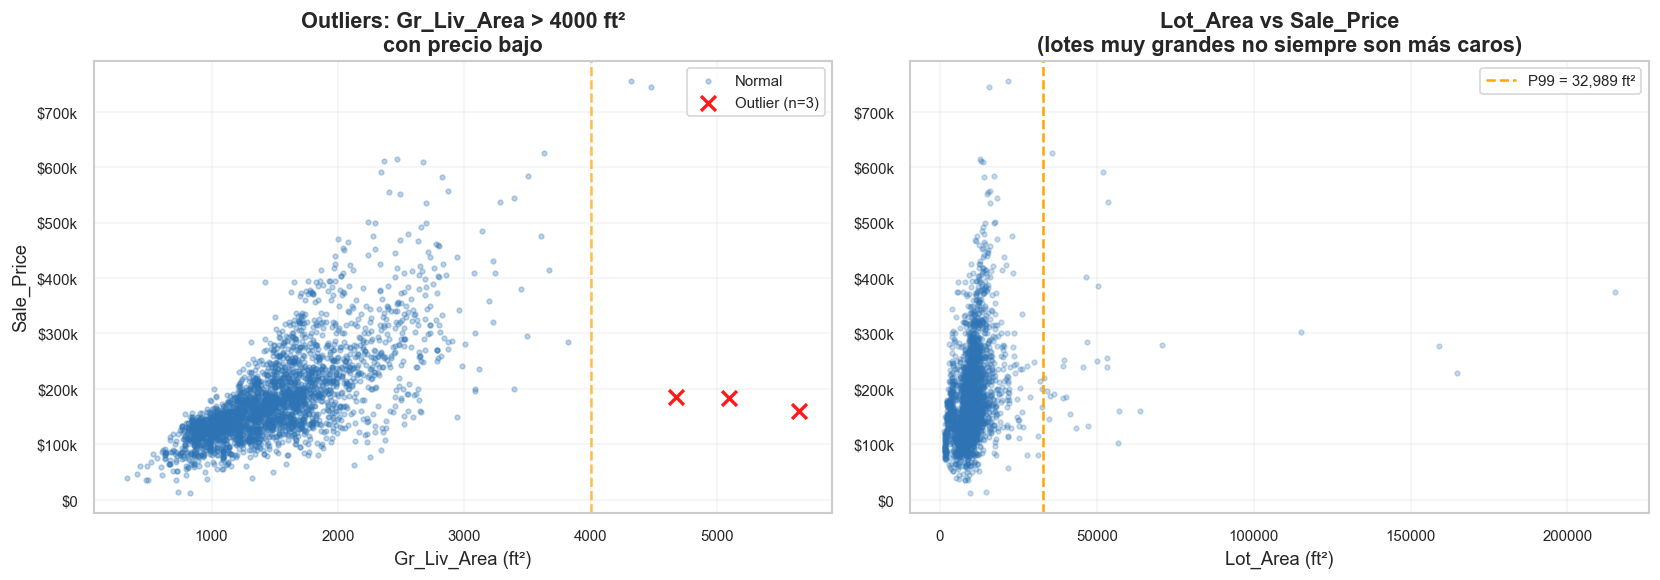

💡 HALLAZGO: 3 propiedades atípicas identificadas.
   Gr_Liv_Area > 4000 ft² con precio < $300,000 → ventas no-residenciales.
   ACCIÓN: Excluirlas del conjunto de entrenamiento (recomendado por De Cock, 2011).


In [16]:
# ── Identificar outliers documentados por De Cock (2011) ────────────────────
# Son propiedades con Gr_Liv_Area > 4000 y precio anormalmente bajo
# Corresponden a ventas parciales de terreno o propiedades no residenciales

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Gr_Liv_Area vs Sale_Price
outliers_mask = (df['Gr_Liv_Area'] > 4000) & (df['Sale_Price'] < 300000)
normal_mask   = ~outliers_mask

axes[0].scatter(df.loc[normal_mask, 'Gr_Liv_Area'], df.loc[normal_mask, 'Sale_Price'],
                alpha=0.3, s=8, color='#2E74B5', label='Normal')
axes[0].scatter(df.loc[outliers_mask, 'Gr_Liv_Area'], df.loc[outliers_mask, 'Sale_Price'],
                alpha=0.9, s=80, color='red', marker='x', linewidth=2, label=f'Outlier (n={outliers_mask.sum()})')
axes[0].axvline(x=4000, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(usd_formatter))
axes[0].set_xlabel('Gr_Liv_Area (ft²)')
axes[0].set_ylabel('Sale_Price')
axes[0].set_title('Outliers: Gr_Liv_Area > 4000 ft²\ncon precio bajo', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# Lote: Lot_Area
lot_q99 = df['Lot_Area'].quantile(0.99)
axes[1].scatter(df['Lot_Area'], df['Sale_Price'], alpha=0.25, s=8, color='#2E74B5')
axes[1].axvline(x=lot_q99, color='orange', linestyle='--', linewidth=1.5,
                label=f'P99 = {lot_q99:,.0f} ft²')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(usd_formatter))
axes[1].set_xlabel('Lot_Area (ft²)')
axes[1].set_title('Lot_Area vs Sale_Price\n(lotes muy grandes no siempre son más caros)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
save_fig('09_outliers')
plt.show()

print(f'💡 HALLAZGO: {outliers_mask.sum()} propiedades atípicas identificadas.')
print('   Gr_Liv_Area > 4000 ft² con precio < $300,000 → ventas no-residenciales.')
print('   ACCIÓN: Excluirlas del conjunto de entrenamiento (recomendado por De Cock, 2011).')

## 7. Distribución de Variables Numéricas con Alta Skewness

[Fig] Guardada: reports/figures\10_skewed_features.png


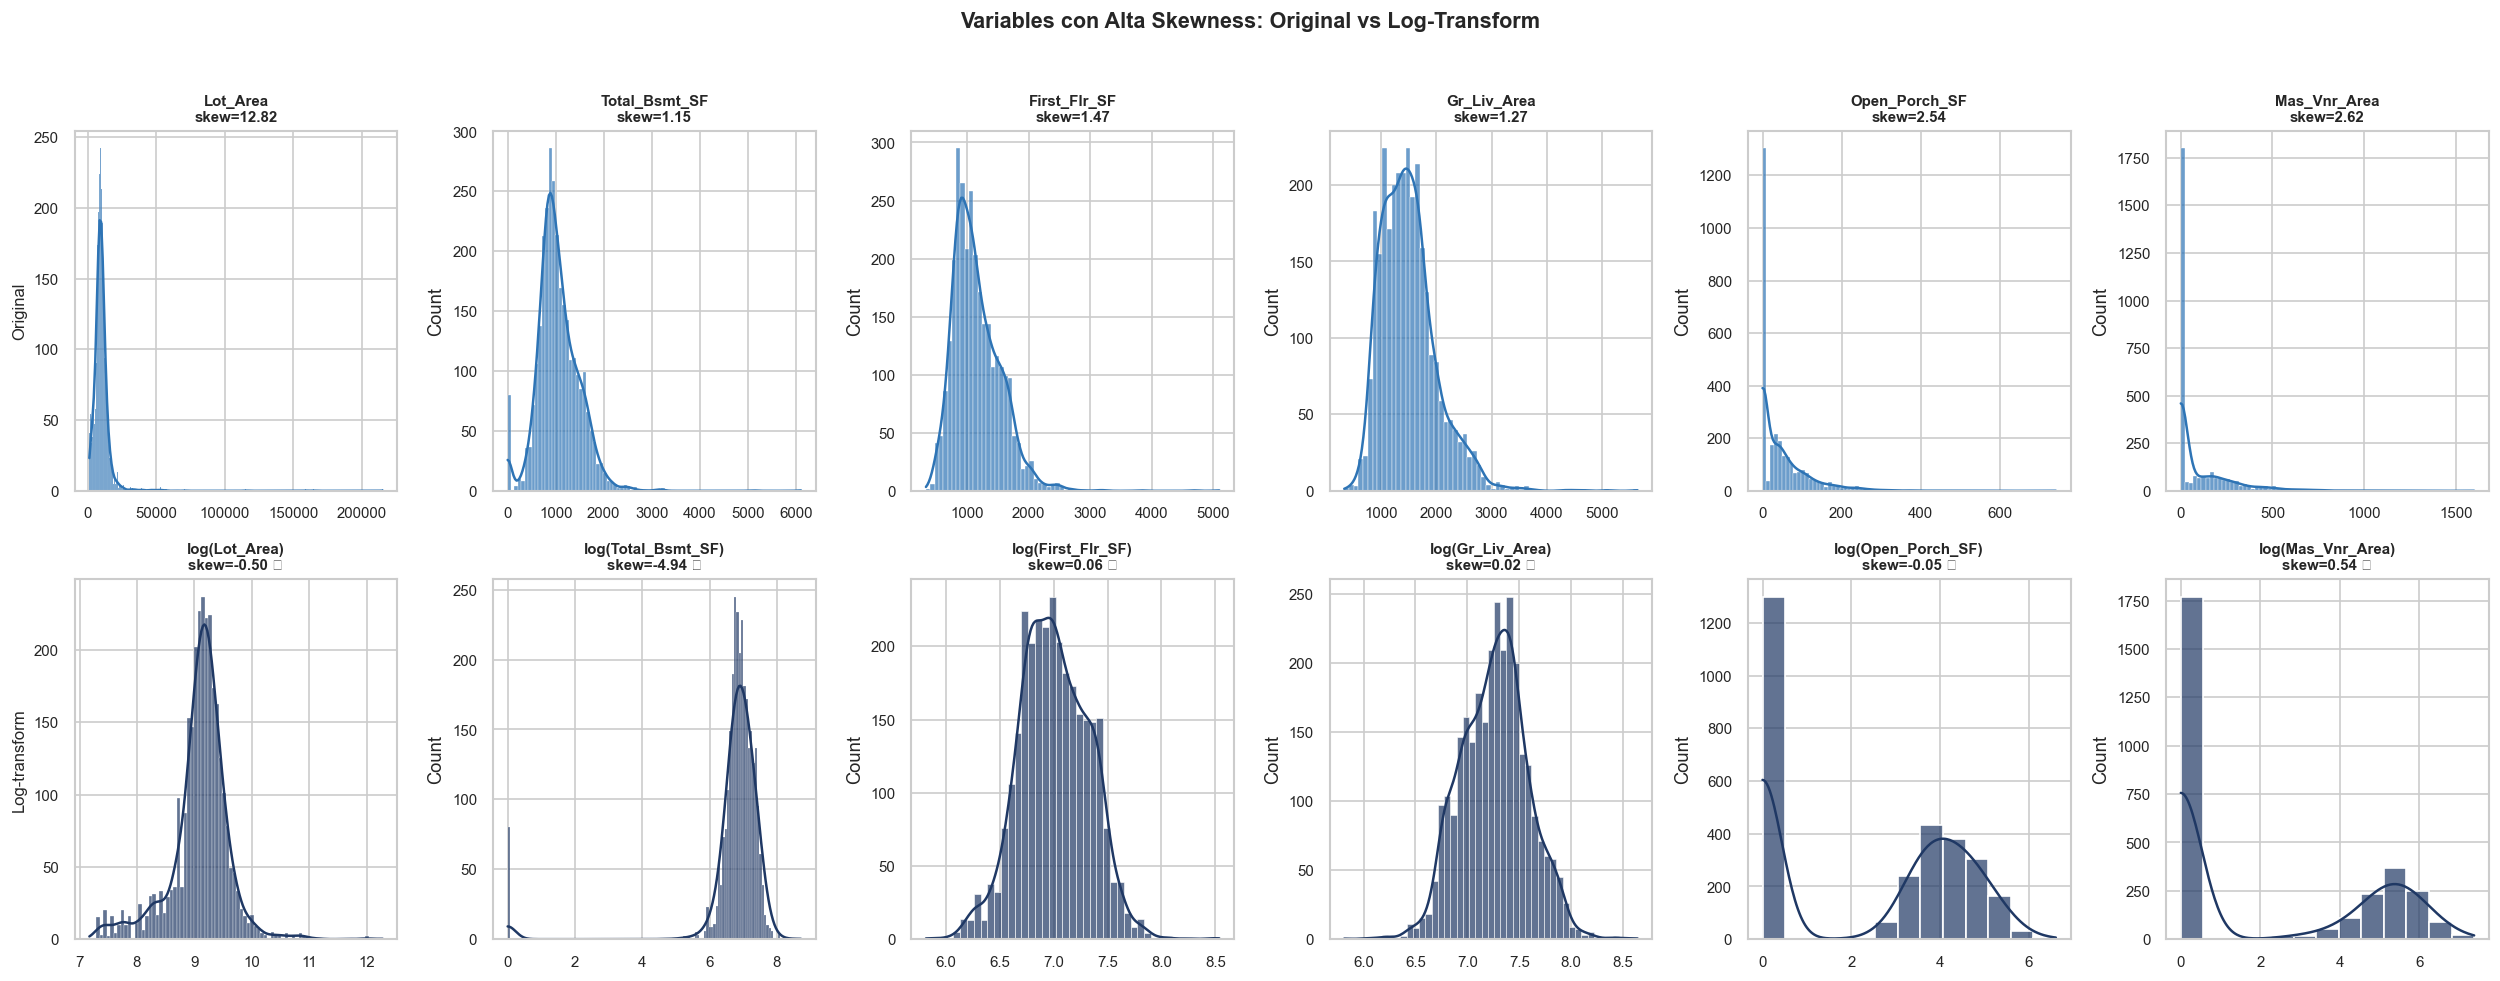

💡 HALLAZGO: Aplicar log1p() normaliza estas distribuciones,
   mejorando el desempeño de modelos paramétricos (Ridge/Lasso).


In [17]:
# ── Variables con alta skewness → candidatas a log-transform ─────────────────
# Si aplicamos log al feature, la relación con Sale_Price puede volverse más lineal

high_skew_cols = ['Lot_Area', 'Total_Bsmt_SF', 'First_Flr_SF', 'Gr_Liv_Area',
                  'Open_Porch_SF', 'Mas_Vnr_Area']
high_skew_cols = [c for c in high_skew_cols if c in df.columns]

n = len(high_skew_cols)
fig, axes = plt.subplots(2, n, figsize=(n*3.5, 8))

for i, col in enumerate(high_skew_cols):
    # Original
    sns.histplot(df[col], kde=True, ax=axes[0, i], color='#2E74B5', alpha=0.7)
    skew_val = df[col].skew()
    axes[0, i].set_title(f'{col}\nskew={skew_val:.2f}', fontsize=9, fontweight='bold')
    axes[0, i].set_xlabel('')

    # Log-transformed
    log_vals = np.log1p(df[col].clip(lower=0))
    sns.histplot(log_vals, kde=True, ax=axes[1, i], color='#1F3864', alpha=0.7)
    log_skew = log_vals.skew()
    axes[1, i].set_title(f'log({col})\nskew={log_skew:.2f} ✅', fontsize=9, fontweight='bold')
    axes[1, i].set_xlabel('')

axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Log-transform', fontsize=10)

plt.suptitle('Variables con Alta Skewness: Original vs Log-Transform', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('10_skewed_features')
plt.show()

print('💡 HALLAZGO: Aplicar log1p() normaliza estas distribuciones,')
print('   mejorando el desempeño de modelos paramétricos (Ridge/Lasso).')

## 8. Resumen de Hallazgos EDA

In [18]:
# ── Resumen ejecutivo del EDA ────────────────────────────────────────────────

print('=' * 65)
print('  RESUMEN DE HALLAZGOS — EDA Ames Housing (Grupo 4)')
print('=' * 65)

hallazgos = [
    ('TARGET',      'Sale_Price tiene skewness=1.88 → aplicar log1p() como target'),
    ('MISSING',     'La versión OpenML no tiene NaN reales, pero categorías como'),
    ('',            '"No_Basement" representan ausencia → mapear a 0 (ordinal)'),
    ('OUTLIERS',    'Excluir propiedades con Gr_Liv_Area > 4000 ft² y precio bajo'),
    ('CORR TOP1',   'Overall_Qual (r=0.79) → codificar como ordinal numérico'),
    ('CORR TOP2',   'Gr_Liv_Area (r≈0.71) → relación lineal con precio en log-scale'),
    ('CORR TOP3',   'Garage_Cars (r≈0.64) ↔ Garage_Area (r≈0.65) → multicolinealidad'),
    ('VECINDARIO',  'Neighborhood: ratio precio max/min ≈ 4-5x → Target Encoding'),
    ('MULTICOLN',   'First_Flr_SF ↔ Total_Bsmt_SF | Garage_Cars ↔ Garage_Area'),
    ('SKEWNESS',    'Lot_Area, Mas_Vnr_Area, Open_Porch_SF → log1p reduce skew'),
    ('TEMPORAL',    'Leve caída de precios en 2008-2009 (crisis), pero mercado estable'),
    ('VENTA ANORM', '~7-8% de ventas son Abnorml/Partial → pueden afectar modelos'),
]

for tag, msg in hallazgos:
    if tag:
        print(f'\n  [{tag:12s}] {msg}')
    else:
        print(f'  {"":16s} {msg}')

print('\n' + '=' * 65)
print('  → Siguiente paso: Notebook 02 — Data Preparation & Pipeline')
print('=' * 65)

  RESUMEN DE HALLAZGOS — EDA Ames Housing (Grupo 4)

  [TARGET      ] Sale_Price tiene skewness=1.88 → aplicar log1p() como target

  [MISSING     ] La versión OpenML no tiene NaN reales, pero categorías como
                   "No_Basement" representan ausencia → mapear a 0 (ordinal)

  [OUTLIERS    ] Excluir propiedades con Gr_Liv_Area > 4000 ft² y precio bajo

  [CORR TOP1   ] Overall_Qual (r=0.79) → codificar como ordinal numérico

  [CORR TOP2   ] Gr_Liv_Area (r≈0.71) → relación lineal con precio en log-scale

  [CORR TOP3   ] Garage_Cars (r≈0.64) ↔ Garage_Area (r≈0.65) → multicolinealidad

  [VECINDARIO  ] Neighborhood: ratio precio max/min ≈ 4-5x → Target Encoding

  [MULTICOLN   ] First_Flr_SF ↔ Total_Bsmt_SF | Garage_Cars ↔ Garage_Area

  [SKEWNESS    ] Lot_Area, Mas_Vnr_Area, Open_Porch_SF → log1p reduce skew

  [TEMPORAL    ] Leve caída de precios en 2008-2009 (crisis), pero mercado estable

  [VENTA ANORM ] ~7-8% de ventas son Abnorml/Partial → pueden afectar modelos

  → S